# CICIoV2024 — Exploratory Data Analysis

This notebook explores the **CICIoV2024** in-vehicle CAN-bus intrusion dataset.

**What is EDA?** *Exploratory Data Analysis* is the investigation you do **before**
building any model: understand the data's shape, check its quality, and surface
patterns. The goal here is *understanding*, not prediction.

Each section starts with a plain-language explanation, then the code, then the
result. We focus on the **decimal** encoding (the cleanest, and the one used by
the existing SVM notebook), verify it against the **hexadecimal** encoding, and
add a short note on the **binary** encoding.

## 0. Setup

We import libraries and our helper module `eda_utils` (in `../src`), which holds
the data loaders and plotting helpers. We also create the `outputs/` folders
where figures and tables are saved.

In [1]:
import sys
from pathlib import Path

import numpy as np                  # numerical arrays / math
import pandas as pd                 # tables (DataFrames) and CSV reading
import matplotlib.pyplot as plt     # base plotting library
import seaborn as sns               # nicer statistical charts on top of matplotlib

# The notebook lives in notebooks/, but our helper code is in ../src.
# We add that folder to Python's import path so `import eda_utils` works.
SRC = Path.cwd().parent / "src"     # when running from notebooks/
if not SRC.exists():                # fallback if Jupyter started at project root
    SRC = Path.cwd() / "src"
sys.path.insert(0, str(SRC))

import eda_utils as eu  # noqa: E402  (import after sys.path tweak, on purpose)

eu.ensure_output_dirs()             # create outputs/figures and outputs/tables
sns.set_theme(style="whitegrid")    # consistent, readable chart style
pd.set_option("display.max_columns", 50)  # show wide tables without truncation

print("pandas", pd.__version__, "| numpy", np.__version__)
print("Data dir:", eu.DATA_DIR)
print("Outputs ->", eu.OUTPUTS_DIR)

pandas 2.0.3 | numpy 1.24.4
Data dir: /home/aelkhate/p/projects/eda_security
Outputs -> /home/aelkhate/p/projects/eda_security/outputs


## 1. Introduction & objectives

**CAN bus (Controller Area Network)** is the internal network that lets a
vehicle's electronic control units (ECUs) — engine, brakes, steering, dashboard —
talk to each other. Every message ("frame") has:

- an **ID** that identifies which subsystem/sensor sent it, and
- up to **8 data bytes** (`DATA_0..DATA_7`) carrying the actual values.

CAN has **no authentication**: any device on the bus can send any message, which
is what makes the attacks below possible.

**The six classes** in this dataset:

| Class | Meaning |
|---|---|
| `BENIGN` | Normal, legitimate traffic. |
| `DoS` | *Denial of Service* — flooding the bus so real messages can't get through. |
| `GAS` | Spoofing the **gas/accelerator** sensor with fake frames. |
| `RPM` | Spoofing the **engine RPM** reading. |
| `SPEED` | Spoofing the **vehicle speed** reading. |
| `STEERING_WHEEL` | Spoofing the **steering angle** reading. |

The data was captured on a **controlled lab bench** (the `Interface` is
`slcan0`, an SLCAN USB-to-CAN adapter) with attacks deliberately injected.

**EDA objectives:** understand the schema, check data quality (especially
duplicates and imbalance), see how separable the classes are, and produce
recommendations for the modeling phase.

## 2. Data loading & schema reconciliation

The same records exist in three encodings whose columns do **not** line up:

| Encoding | Columns | Layout |
|---|---|---|
| decimal | 12 | `ID`, `DATA_0..7` (0-255), + 3 label columns |
| hexadecimal | 13-14 | `Interface`, `ID` (hex), `DLC`, `DATA_0..7` (hex), + labels |
| binary | 156 | `ID0..ID16` (bits) + DATA bit-columns + labels |

`DLC` = **Data Length Code** (how many data bytes the frame carries; always
`[8]` here). One real quirk: the **hexadecimal DoS file is missing the `DLC`
column**. Our loader aligns columns *by name*, so that missing column simply
becomes `NaN` for those rows instead of corrupting the table.

**Memory note — downcasting is lossless.** We store each data byte as `uint8`
(0-255) and each CAN ID as `uint16` (0-2047). These types exactly fit the value
ranges, so no precision is lost; we just use far less RAM.

In [2]:
# Load the FULL decimal encoding: all 6 class files stacked into one table.
# (~1.41M rows = 1.22M benign + ~184k attacks.)
dec = eu.load_encoding("decimal")

# .shape is (rows, columns). .memory_usage(deep=True) sums bytes used; /1e6 -> MB.
print("Decimal shape:", dec.shape)
print("Memory: {:.1f} MB".format(dec.memory_usage(deep=True).sum() / 1e6))

# Show each column's data type. Thanks to downcasting, bytes are uint8 and ID is
# uint16 (small types) instead of the default 8-byte int64.
dec.dtypes

Decimal shape: (1408219, 12)
Memory: 279.9 MB


ID                uint16
DATA_0             uint8
DATA_1             uint8
DATA_2             uint8
DATA_3             uint8
DATA_4             uint8
DATA_5             uint8
DATA_6             uint8
DATA_7             uint8
label             object
category          object
specific_class    object
dtype: object

In [3]:
# Peek at the first 5 rows so we can see the actual structure:
# ID + DATA_0..DATA_7 (the features) followed by label/category/specific_class.
dec.head()

,ID,DATA_0,DATA_1,DATA_2,DATA_3,DATA_4,DATA_5,DATA_6,DATA_7,label,category,specific_class
0,65,96,0,0,0,0,0,0,0,BENIGN,BENIGN,BENIGN
1,1068,132,13,160,0,0,0,0,0,BENIGN,BENIGN,BENIGN
2,535,127,255,127,255,127,255,127,255,BENIGN,BENIGN,BENIGN
3,131,15,224,0,0,0,0,0,0,BENIGN,BENIGN,BENIGN
4,936,1,0,39,16,0,0,0,0,BENIGN,BENIGN,BENIGN


In [4]:
# Load the hexadecimal encoding too, but ONLY to cross-check it against decimal
# (Section 3.5). downcast=False keeps the hex strings (e.g. '42C') as text.
hexd = eu.load_encoding("hexadecimal", downcast=False)
print("Hex shape:", hexd.shape)

# The hex DoS file is missing the DLC column. After aligning columns by name,
# those DoS rows have NaN in DLC. The count of NaNs should equal the DoS rows.
print("DLC nulls (should equal the DoS row count):", int(hexd["DLC"].isna().sum()))
hexd.head()

Hex shape: (1408219, 14)
DLC nulls (should equal the DoS row count): 74663


,Interface,ID,DLC,DATA_0,DATA_1,DATA_2,DATA_3,DATA_4,DATA_5,DATA_6,DATA_7,label,category,specific_class
0,slcan0,041,[8],60,00,00,00,00,00,00,00,BENIGN,BENIGN,BENIGN
1,slcan0,42C,[8],84,0D,A0,00,00,00,00,00,BENIGN,BENIGN,BENIGN
2,slcan0,217,[8],7F,FF,7F,FF,7F,FF,7F,FF,BENIGN,BENIGN,BENIGN
3,slcan0,083,[8],0F,E0,00,00,00,00,00,00,BENIGN,BENIGN,BENIGN
4,slcan0,3A8,[8],01,00,27,10,00,00,00,00,BENIGN,BENIGN,BENIGN


**Result read-out (Section 2).** The decimal table is ~1.41M rows × 12 columns and,
thanks to downcasting, uses a fraction of the memory it otherwise would. The hex
table has the same number of rows; the only missing values are in `DLC`, exactly
for the DoS rows — confirming the missing-column quirk is handled correctly (the
values did not shift into the wrong columns).

## 3. Data quality assessment

We check the data is trustworthy before analyzing it.

### 3.1 Missing values

We expect **no** missing values in decimal. In hexadecimal, only `DLC` is
missing, and only for the DoS rows (because that file lacks the column).

In [5]:
# .isna() marks every empty cell as True; .sum() counts them per column.
print("Decimal missing values per column:")
print(dec.isna().sum().to_string())

# For hex, show only columns that actually have missing values (count > 0).
print("\nHex missing values (non-zero only):")
print(hexd.isna().sum().loc[lambda s: s > 0].to_string() or "none")

Decimal missing values per column:
ID                0
DATA_0            0
DATA_1            0
DATA_2            0
DATA_3            0
DATA_4            0
DATA_5            0
DATA_6            0
DATA_7            0
label             0
category          0
specific_class    0

Hex missing values (non-zero only):


DLC    74663


### 3.2 Duplicate rows — the most important quality finding

**Why this matters.** A *duplicate* row is an exact copy of another row. We will
see that each attack class consists of only a **handful of unique frames**
repeated tens of thousands of times. That is normal for these attacks (they
inject the *same* forged message over and over), but it has a critical
consequence for modeling:

> If you split the data randomly into train/test, **identical copies land in
> both halves**. The model "memorizes" a frame in training and then "recognizes"
> the same frame in the test set. The score looks near-perfect, but it measures
> memorization, not the ability to handle new attacks. This is called
> **data leakage**.

**We do NOT delete duplicates** — removing them would shrink the attacks to ~41
rows and destroy the dataset. The correct fix (applied in the modeling phase) is
a **group-aware split**: treat each unique frame as a group and keep each group
entirely in train *or* test, never both.

In [6]:
# .duplicated() returns True for every row that is an exact copy of an earlier
# row; .sum() counts them. This is the "how much repetition?" number.
total_dupes = int(dec.duplicated().sum())
print(f"Exact duplicate rows in decimal: {total_dupes:,} "
      f"({100 * total_dupes / len(dec):.2f}% of all rows)")

# Per-class breakdown: total rows vs how many DISTINCT frames each class has.
frame_counts = eu.unique_frame_counts(dec)
eu.save_table(frame_counts, "unique_frames_per_class")  # -> outputs/tables/
frame_counts

Exact duplicate rows in decimal: 1,404,631 (99.75% of all rows)


,rows,unique_frames
specific_class,,
BENIGN,1223737,3547
DoS,74663,21
GAS,9991,2
RPM,54900,10
SPEED,24951,5
STEERING_WHEEL,19977,3


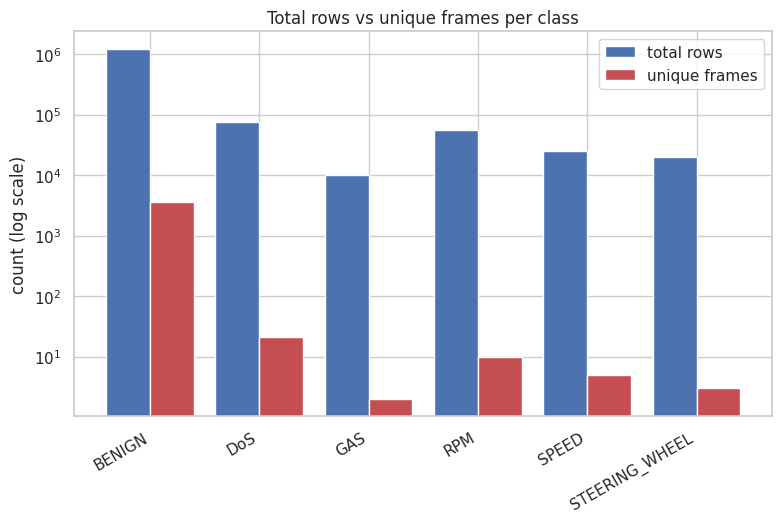

In [7]:
# Grouped bar chart: for each class, "total rows" vs "unique frames" side by side.
fig, ax = plt.subplots(figsize=(9, 5))
idx = np.arange(len(frame_counts))   # x positions 0,1,2,... one per class
w = 0.4                              # bar width; we offset two bars by +/- w/2
# Left bar = total rows, right bar = unique frames.
ax.bar(idx - w/2, frame_counts["rows"], width=w, label="total rows", color="#4C72B0")
ax.bar(idx + w/2, frame_counts["unique_frames"], width=w, label="unique frames", color="#C44E52")
# Log scale because benign (~1.2M) and GAS unique frames (2) differ by ~6 orders
# of magnitude; a linear axis would make the small bars invisible.
ax.set_yscale("log")
ax.set_xticks(idx)
ax.set_xticklabels(frame_counts.index, rotation=30, ha="right")
ax.set_ylabel("count (log scale)")
ax.set_title("Total rows vs unique frames per class")
ax.legend()
eu.save_fig(fig, "rows_vs_unique_frames")  # save PNG before showing
plt.show()

### 3.3 Constant (zero-variance) columns

A column with only one value carries no information for a model and can be
dropped. In hexadecimal, `Interface` is always `slcan0` and `DLC` is always
`[8]`. Decimal has no such columns.

In [8]:
# A column with only ONE distinct value carries no information for a model.
# .dropna() ignores missing cells; .unique() lists the distinct values.
for col in ["Interface", "DLC"]:
    if col in hexd.columns:
        print(f"hex['{col}'] unique values:", hexd[col].dropna().unique()[:5])

hex['Interface'] unique values: ['slcan0']
hex['DLC'] unique values: ['[8]']


### 3.4 Value-range sanity check

Decimal data bytes must lie in **[0, 255]** (one byte) and the CAN ID in
**[0, 2047]** (11-bit standard CAN identifier).

In [9]:
# Collect the 8 payload byte columns by name.
data_cols = [c for c in dec.columns if c.startswith("DATA_")]
# .min().min() = the smallest value across ALL byte columns (min of per-column
# mins); likewise .max().max() for the largest. Expect 0 and 255 (one byte).
print("DATA byte min/max:", int(dec[data_cols].min().min()), "/", int(dec[data_cols].max().max()))
# CAN standard IDs are 11-bit, so the range should be within 0..2047.
print("ID min/max:", int(dec["ID"].min()), "/", int(dec["ID"].max()))

DATA byte min/max: 0 / 255
ID min/max: 65 / 1438


### 3.5 Cross-encoding consistency

The decimal and hexadecimal files should describe the **same** frames. We decode
a sample of hex values to integers and confirm they match decimal exactly.

In [10]:
# FULL-dataset check (not a sample): decode every hex field to an integer and
# compare it to the decimal value, field by field, across all rows. The two
# tables share the same row order, so we can compare the underlying arrays.
fields = ["ID"] + data_cols
mismatch_by_field = {}
for c in fields:
    parsed = eu.hex_series_to_int(hexd[c]).values   # hex -> int, whole column
    mismatch_by_field[c] = int((parsed != dec[c].values).sum())

total_cells = len(dec) * len(fields)
total_mismatch = sum(mismatch_by_field.values())
print(f"Compared {total_cells:,} cells across {len(fields)} fields x {len(dec):,} rows")
print("Mismatches by field (showing non-zero):")
for c, m in mismatch_by_field.items():
    if m:
        print(f"  {c}: {m:,}")
print(f"Total mismatches: {total_mismatch:,} "
      f"({100*total_mismatch/total_cells:.4f}% of all cells)")

Compared 12,673,971 cells across 9 fields x 1,408,219 rows
Mismatches by field (showing non-zero):
  DATA_6: 4,989
Total mismatches: 4,989 (0.0394% of all cells)


**Result read-out (Section 3.5).** Checking the *entire* dataset (not a sample)
shows hex and decimal are identical for the ID and 7 of 8 payload bytes. The only
discrepancy is in the hexadecimal **SPEED** file's `DATA_6` column, which stores
float-formatted strings (`0.0`, `2.0`) instead of hex bytes — a defect in that
source file. The decimal encoding has the correct values, reinforcing our choice
of decimal as the primary representation.

## 4. Target / class distribution

The **target** is the column we would eventually predict. There are three label
columns of increasing detail: `label` (2 classes) -> `category` (3) ->
`specific_class` (6). We focus on `specific_class`.

**Class imbalance** means some classes have far more rows than others. Here
benign dwarfs every attack. This matters because plain **accuracy** can look
excellent while the model quietly fails on the rare classes — so later we will
prefer per-class metrics and class weighting.

In [11]:
# .value_counts() tallies rows per class; .reindex() puts them in our order.
dist = dec["specific_class"].value_counts().reindex(eu.CLASS_ORDER)
# Convert counts to percentages of the whole dataset.
dist_pct = (100 * dist / dist.sum()).round(3)
# Put count and percent side by side and save the table.
dist_table = pd.DataFrame({"count": dist, "percent": dist_pct})
eu.save_table(dist_table, "class_distribution")
# Imbalance ratio = biggest class size / smallest class size.
imbalance = dist.max() / dist.min()
print(f"Imbalance ratio (largest / smallest class): {imbalance:,.1f} : 1")
dist_table

Imbalance ratio (largest / smallest class): 122.5 : 1


,count,percent
specific_class,,
BENIGN,1223737,86.900
DoS,74663,5.302
GAS,9991,0.709
RPM,54900,3.899
SPEED,24951,1.772
STEERING_WHEEL,19977,1.419


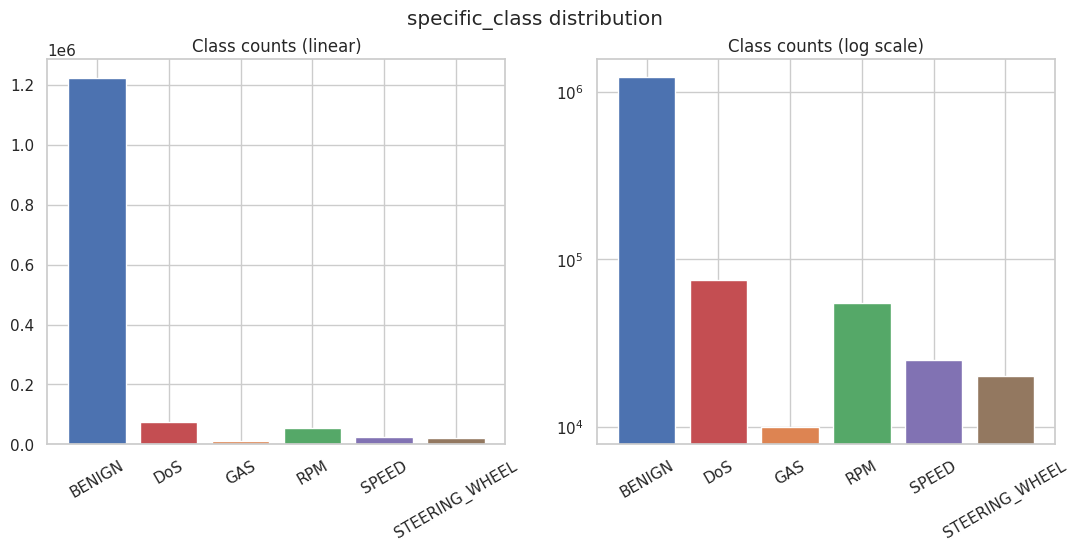

In [12]:
# Two panels side by side: linear scale (left) and log scale (right).
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = [eu.CLASS_PALETTE[c] for c in dist.index]  # consistent per-class colors
# Left: linear axis. Benign dominates so the attacks look almost flat at zero.
axes[0].bar(dist.index, dist.values, color=colors)
axes[0].set_title("Class counts (linear)")
axes[0].tick_params(axis="x", rotation=30)
# Right: same data on a log axis, which makes the small attack classes visible.
axes[1].bar(dist.index, dist.values, color=colors)
axes[1].set_yscale("log")
axes[1].set_title("Class counts (log scale)")
axes[1].tick_params(axis="x", rotation=30)
fig.suptitle("specific_class distribution")
eu.save_fig(fig, "class_distribution")
plt.show()

**Result read-out (Section 4).** Benign is ~87% of all rows and the imbalance
ratio is about **122 : 1** (benign vs the smallest attack, GAS). This is why we
must not judge models by accuracy alone, and why we later use class weighting and
per-class metrics.

## 5. CAN ID analysis

The `ID` says which subsystem sent a frame. A key question for intrusion
detection: **do attacks use IDs that benign traffic never uses?** If so, the ID
alone almost solves the problem.

In [13]:
# For each class, count how many DISTINCT CAN IDs it uses (.nunique()).
ids_per_class = dec.groupby("specific_class", observed=True)["ID"].nunique().reindex(eu.CLASS_ORDER)
print("Distinct CAN IDs per class:")
print(ids_per_class.to_string())

# Build the SET of IDs that appear in benign traffic.
benign_ids = set(dec.loc[dec["specific_class"] == "BENIGN", "ID"].unique())

# For each attack, compute the set of IDs it uses, then INTERSECT (&) with the
# benign IDs. The intersection = IDs shared by both = "overlap".
# An empty overlap ([]) means: this attack uses IDs benign NEVER uses, so the ID
# alone separates the attack from normal traffic.
print("\nDoes each attack reuse benign IDs, or use its own?")
for cls in ["DoS", "GAS", "RPM", "SPEED", "STEERING_WHEEL"]:
    cls_ids = set(dec.loc[dec["specific_class"] == cls, "ID"].unique())
    overlap = cls_ids & benign_ids   # set intersection
    print(f"  {cls:15s} IDs={sorted(cls_ids)!s:20s} overlap_with_benign={sorted(overlap)}")

Distinct CAN IDs per class:
specific_class
BENIGN            72
DoS                1
GAS                1
RPM                2
SPEED              2
STEERING_WHEEL     1

Does each attack reuse benign IDs, or use its own?
  DoS             IDs=[291]                overlap_with_benign=[]
  GAS             IDs=[513]                overlap_with_benign=[]
  RPM             IDs=[476, 513]           overlap_with_benign=[]
  SPEED           IDs=[344, 513]           overlap_with_benign=[]
  STEERING_WHEEL  IDs=[128]                overlap_with_benign=[]


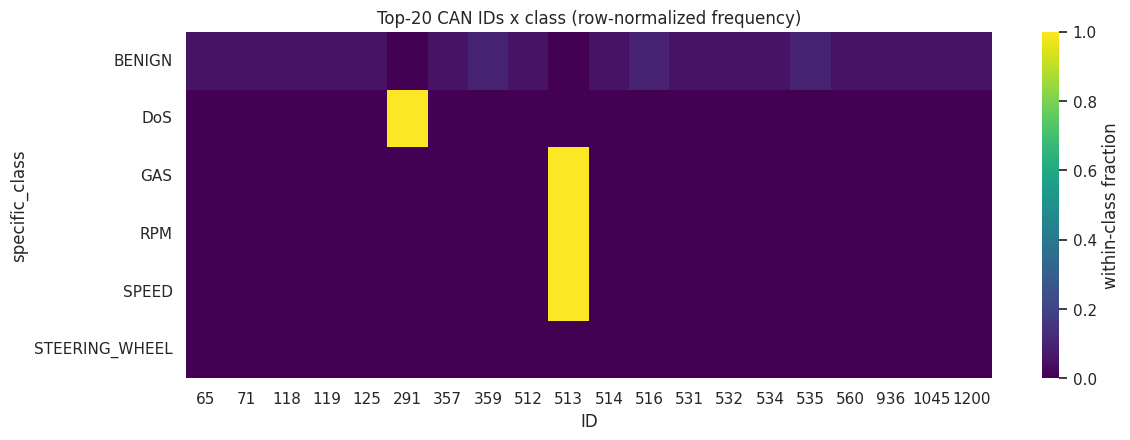

In [14]:
# Pick the 20 most common IDs overall (keeps the heatmap readable).
top_ids = dec["ID"].value_counts().head(20).index
# pivot_table builds a grid: rows = class, columns = ID, cell = count of frames
# (aggfunc="size"). Missing combinations become 0.
pivot = (dec[dec["ID"].isin(top_ids)]
         .pivot_table(index="specific_class", columns="ID", aggfunc="size", fill_value=0)
         .reindex(eu.CLASS_ORDER))
# Row-normalize: divide each row by its own total so every class sums to 1.
# This shows, WITHIN a class, how its frames are distributed across IDs.
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0).fillna(0)
fig, ax = plt.subplots(figsize=(13, 4.5))
# A heatmap = colored grid; brighter = larger fraction.
sns.heatmap(pivot_norm, cmap="viridis", ax=ax, cbar_kws={"label": "within-class fraction"})
ax.set_title("Top-20 CAN IDs x class (row-normalized frequency)")
eu.save_fig(fig, "can_id_class_heatmap")
plt.show()

**Result read-out (Section 5).** Benign traffic spreads across **72** IDs, while
each attack uses just **1-2** IDs. Every attack's `overlap_with_benign` is empty
(`[]`) — i.e. **no benign overlap**: attacks ride on CAN IDs that normal traffic
never uses. In the heatmap, each attack row lights up in its own column(s),
visually separate from benign. (GAS/RPM/SPEED happen to share ID 513 with each
other, but still none overlap benign.)

## 6. Payload (DATA byte) analysis — decimal

Now the 8 data bytes. We look at how their values are distributed, and how that
differs between benign and attack traffic.

**Entropy** is a measure of randomness/variety: high entropy = many different
values; low entropy = the same few values repeated. Attacks inject a fixed
forged payload, so we expect their bytes to have **very low entropy** compared to
benign traffic.

> We intentionally **omit** a byte-to-byte correlation heatmap: CAN payload bytes
> encode unrelated physical signals (and checksums), so there is no reason to
> expect them to be correlated — measuring it would add noise, not insight.

In [15]:
# .describe() gives count/mean/std/min/quartiles/max per column; .T transposes
# so each byte is a row. We keep the 4 most useful stats.
dec[data_cols].describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
DATA_0,71.086599,88.977175,0.0,255.0
DATA_1,69.989250,95.583743,0.0,255.0
DATA_2,55.011272,72.765838,0.0,255.0
DATA_3,57.453638,90.320766,0.0,255.0
DATA_4,45.285167,64.458350,0.0,255.0
DATA_5,53.882613,94.336120,0.0,255.0
DATA_6,71.749144,101.687183,0.0,255.0
DATA_7,60.274769,99.965467,0.0,255.0


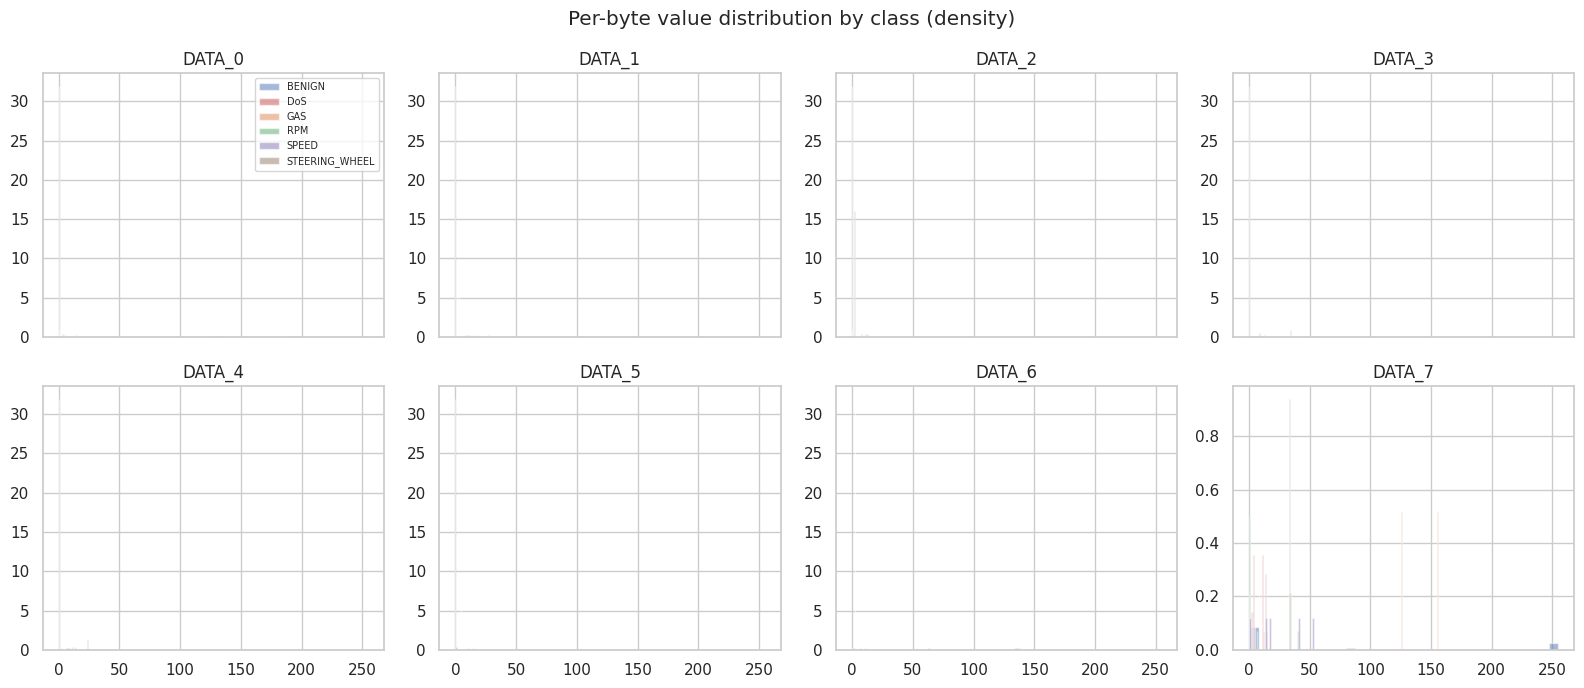

In [16]:
# "Small multiples": a 2x4 grid, one mini-histogram per data byte.
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
# axes.ravel() flattens the 2x4 grid to a list so we can pair it with the 8 cols.
for ax, col in zip(axes.ravel(), data_cols):
    # Overlay one histogram per class on the same mini-plot.
    for cls in eu.CLASS_ORDER:
        vals = dec.loc[dec["specific_class"] == cls, col]   # this class's values
        # bins=32 buckets; alpha=0.5 = semi-transparent so overlaps show;
        # density=True normalizes areas to 1 so classes of different sizes are
        # comparable (otherwise benign would dwarf everything).
        ax.hist(vals, bins=32, alpha=0.5, label=cls, color=eu.CLASS_PALETTE[cls], density=True)
    ax.set_title(col)
axes[0, 0].legend(fontsize=7)
fig.suptitle("Per-byte value distribution by class (density)")
fig.tight_layout()
eu.save_fig(fig, "payload_byte_distributions")
plt.show()

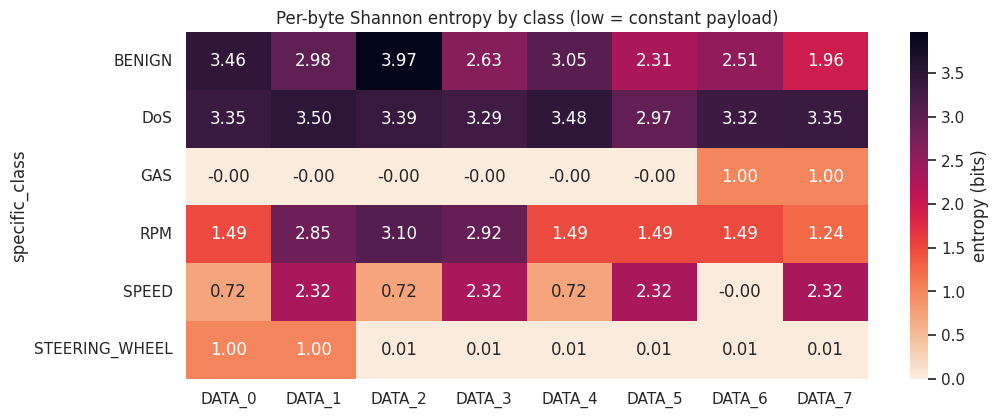

In [17]:
def shannon_entropy(series: pd.Series) -> float:
    """Shannon entropy (bits) of a discrete series of byte values.

    Entropy measures variety/unpredictability:
      - 0 bits  -> the byte is always the SAME value (perfectly constant).
      - 8 bits  -> all 256 byte values are equally likely (maximally varied).
    """
    # value_counts(normalize=True) gives each value's probability p.
    p = series.value_counts(normalize=True)
    # Shannon's formula: H = -sum(p * log2(p)). Lower = more constant.
    return float(-(p * np.log2(p)).sum())

# Compute entropy of every byte, separately for each class.
ent = (dec.groupby("specific_class", observed=True)[data_cols]
       .agg(shannon_entropy).reindex(eu.CLASS_ORDER))
eu.save_table(ent, "payload_entropy_per_class")
fig, ax = plt.subplots(figsize=(11, 4.5))
# annot=True writes the number in each cell; fmt=".2f" = 2 decimals.
# "rocket_r" reversed colormap: dark = low entropy (constant), light = high.
sns.heatmap(ent, annot=True, fmt=".2f", cmap="rocket_r", ax=ax,
            cbar_kws={"label": "entropy (bits)"})
ax.set_title("Per-byte Shannon entropy by class (low = constant payload)")
eu.save_fig(fig, "payload_entropy_heatmap")
plt.show()

**Result read-out (Section 6).** Attack rows show **much lower entropy** than
benign across most bytes — many attack bytes are near 0, meaning they inject the
same fixed payload over and over. Benign bytes are more varied (higher entropy).
This low-entropy, repetitive nature is exactly what makes the attacks easy to
separate and also what produces the duplicate rows seen in Section 3.

## 7. Binary encoding — short note

The binary encoding is the **same information** as decimal, just "exploded" into
individual bits: the CAN ID becomes 17 bit-columns and the data bytes become
many 0/1 columns (156 columns total vs decimal's 12).

It contains **no extra signal** — it is decimal re-expressed in base 2 — but it
costs far more memory and many more features. For this dataset we therefore
prefer the compact **decimal** encoding for analysis and modeling. We confirm
the structure quickly below without a deep per-bit analysis.

In [18]:
# Read just 3 rows of the binary benign file to inspect its structure cheaply.
bin_head = pd.read_csv(eu.encoding_files("binary")["BENIGN"], nrows=3)
# Count how many columns are ID bits vs DATA bits by their name prefix.
n_id_bits = sum(c.startswith("ID") for c in bin_head.columns)
n_data_bits = sum(c.startswith("DATA_") for c in bin_head.columns)
print(f"binary columns: {bin_head.shape[1]} "
      f"({n_id_bits} ID bits + {n_data_bits} DATA bits + 3 labels)")
# Confirm the feature cells contain only 0s and 1s (true binary).
print("All-binary values in sample:", set(np.unique(bin_head.iloc[:, :n_id_bits + n_data_bits].values)))

binary columns: 156 (17 ID bits + 136 DATA bits + 3 labels)
All-binary values in sample: {0, 1}


## 8. Encoding comparison summary

A compact comparison of the three encodings and a recommendation.

In [19]:
# A hand-built summary table comparing the three encodings (one row each).
comparison = pd.DataFrame(
    {
        "feature_columns": [9, 9, 153],                 # how many model inputs
        "needs_parsing": ["no", "yes (hex->int)", "no"],  # extra work to use it
        "constant_cols": ["none", "Interface, DLC", "none"],  # droppable columns
        "info_content": ["full", "identical to decimal", "identical to decimal"],
        "recommendation": ["PRIMARY", "consistency check", "not needed"],
    },
    index=["decimal", "hexadecimal", "binary"],
)
eu.save_table(comparison, "encoding_comparison")
comparison

,feature_columns,needs_parsing,constant_cols,info_content,recommendation
decimal,9,no,none,full,PRIMARY
hexadecimal,9,yes (hex->int),"Interface, DLC",identical to decimal,consistency check
binary,153,no,none,identical to decimal,not needed


## 9. Attack-signature mini-profiles

For each attack, the single most-common forged frame (its "signature"): the CAN
ID it targets and the exact payload it injects.

In [20]:
profiles = []
for cls in ["DoS", "GAS", "RPM", "SPEED", "STEERING_WHEEL"]:
    sub = dec[dec["specific_class"] == cls]    # rows of just this attack
    frame_cols = ["ID"] + data_cols            # what defines a unique frame
    # value_counts() ranks the (ID, bytes...) combinations by frequency;
    # .head(1) takes the single most common one = the attack's "signature".
    top = sub[frame_cols].value_counts().head(1)
    (frame, count) = next(iter(top.items()))   # frame=the tuple, count=its freq
    profiles.append({
        "class": cls,
        "rows": len(sub),                                   # total rows
        "unique_frames": sub[frame_cols].drop_duplicates().shape[0],  # variety
        "top_ID": frame[0],                                 # the targeted CAN ID
        "top_payload": list(frame[1:]),                     # the injected bytes
        "top_frame_share": round(count / len(sub), 3),      # how dominant it is
    })
profiles_df = pd.DataFrame(profiles).set_index("class")
eu.save_table(profiles_df, "attack_signatures")
profiles_df

,rows,unique_frames,top_ID,top_payload,top_frame_share
class,,,,,
DoS,74663,21,291,"[3, 3, 0, 9, 7, 3, 7, 4]",0.067
GAS,9991,2,513,"[0, 0, 0, 0, 0, 0, 64, 156]",0.500
RPM,54900,10,476,"[2, 61, 23, 19, 0, 0, 0, 0]",0.182
SPEED,24951,5,344,"[6, 16, 6, 54, 6, 29, 2, 14]",0.200
STEERING_WHEEL,19977,3,128,"[132, 3, 2, 35, 24, 5, 138, 34]",0.500


**Result read-out (Section 9).** Each attack has a clear signature: DoS floods
ID **291**, GAS injects ID **513**, RPM ID **476**, SPEED ID **344**, STEERING ID
**128**. For GAS and STEERING a single frame accounts for 50% of all their rows,
confirming how repetitive (low-variety) these attacks are.

## 10. Key findings & recommendations

**Findings**

1. **Three equivalent encodings.** Decimal, hexadecimal and binary describe the
   same frames (verified ~1.0 match rate). Decimal is the cleanest; hexadecimal
   adds two constant columns (`Interface`, `DLC`); binary adds dimensionality
   with no new information.
2. **Severe class imbalance** (~hundreds-to-one benign vs the smallest attack).
   Plain accuracy will be misleading.
3. **Near-deterministic attacks.** Each attack is a handful of unique frames
   (DoS 21, GAS 2, RPM 10, SPEED 5, STEERING 3) repeated many times, and each
   attack uses **its own CAN ID** that benign traffic never uses. Attack payloads
   have very low entropy.
4. **Many duplicate rows** — a natural consequence of (3), but the source of
   train/test **leakage** under a naive random split.

**Recommendations for the modeling phase**

- **Do not deduplicate.** Use a **group-aware split** (group by unique frame) so
  the test set contains frames the model never saw — for an honest score.
- **Handle imbalance**: train with `class_weight='balanced'` and evaluate with
  **per-class** precision/recall/F1 plus a **macro** average and a confusion
  matrix, not the weighted average alone.
- **Use the decimal encoding**; drop constant columns if you switch to hex.
- Because the task is rule-like (an ID almost determines the class), expect
  **tree-based models** (Decision Tree -> Random Forest -> LightGBM) to be a
  better, more interpretable fit than SVM. SVM/Logistic Regression are useful
  only as baselines.

All figures are saved under `outputs/figures/` and all summary tables under
`outputs/tables/`.